# Analysing of Dialogue, Character Prominence, and Episode Ratings in Breaking Bad (Seasons 1–3)
**Team Members:** Eashin Arafat Jihad, Asraf Ali Pathan, Rachel Ishola

**GitHub:** https://github.com/aster87-design/DATA-200/tree/Midterm-Project

---

### 1. Research Question
**Does dialogue quantity and character prominence in Breaking Bad (Seasons 1–3) explain variation in IMDb ratings? How does Walter White’s dialogue share change across seasons based on an OLS regression model, and is there a relationship between on-screen deaths and episode ratings?**

We focus exclusively on Seasons 1–3 across all analyses, as complete script dialogue data is only available for those seasons.

---

### 2. Variable Descriptions

**Continuous variables:**
- `rating` – IMDb rating of the episode (e.g. IMDb 8.5, 9.2)
- `word_count` – Total dialogue words spoken in the episode
- `walter_share` – Proportion of diologue spoken by Walter White (0–1)
- `votes` – Number of IMDb votes for the episode
- `us_viewers` – US viewership iin millions
- `number_of_deaths` – Total on-screen deaths per episode/season

**Categorical variables:**
- `season` – Season number (1–3)
- `episode` – Episode number within the season
- `killer` – Character responsible for a death (from `deaths.csv`)
- `actor` – Character speaking each line of dialogue

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Colour palette inspired by the show
meth_blue   = '#00bfff'
toxic_green = '#026635'

# Load datasets
scripts  = pd.read_csv("breaking_bad_scripts.csv") 
ratings  = pd.read_csv("breaking_bad_ratings.csv")
deaths   = pd.read_csv("deaths.csv").query('season <= 3')

### 3. Data Augmentation/Joining

We join the script dialogue data with episode ratings on `season` and `episode`. Then **restrict everything to Seasons 1–3** where we have complete data coverage of the data for the show.

In [14]:
# change types to int so merging donot fail
scripts['season']  = scripts['season'].astype(int)
scripts['episode'] = scripts['episode'].astype(int)
ratings['season']  = ratings['season'].astype(int)
ratings['episode'] = ratings['episode'].astype(int)

# mergingf season and episode then restrict to Seasons 1–3
breaking_bad = (pd.merge(scripts, ratings, on=['season','episode'], how='inner')
                  .query('season <= 3')
                  .reset_index(drop=True))

### 4. Script Cleaning 

We use a **regular expression** to strip stage directions such as `[laughs]` or `[whispers]` from the dialogue, then count the remaining words per line.

In [15]:
# clean the text using a regex pattern
breaking_bad['clean_text'] = (
    breaking_bad['text'].str.replace(r"\[.*?\]", "", regex=True).str.strip()) # removes words such [laughs], [whispers], [gunshot]

breaking_bad['word_count'] = breaking_bad['clean_text'].str.split().str.len()

### 5. Tidy Data on Episode Level

We aggregate from the dialogue level to the episode level, counting total words, mean IMDb rating, mean votes, and mean US viewership per episode. As thsi gives us a breif image of the data.

In [16]:
# group by season and episode to get the sums and means
episode = breaking_bad.groupby(['season', 'episode']).agg(
    word_count = ('word_count', 'sum'),
    rating     = ('rating',     'mean'),
    votes      = ('votes',      'mean'),
    us_viewers = ('us-viewers', 'mean'),
    title      = ('title_x',   'first')
).reset_index()

# remove episodes that somehow have 0 words
episode = episode[episode['word_count'] > 0].reset_index(drop=True)

### 6. Average Rating by Season

How do average IMDb ratings compare across Seasons 1–3? The line chart below shows the trend.

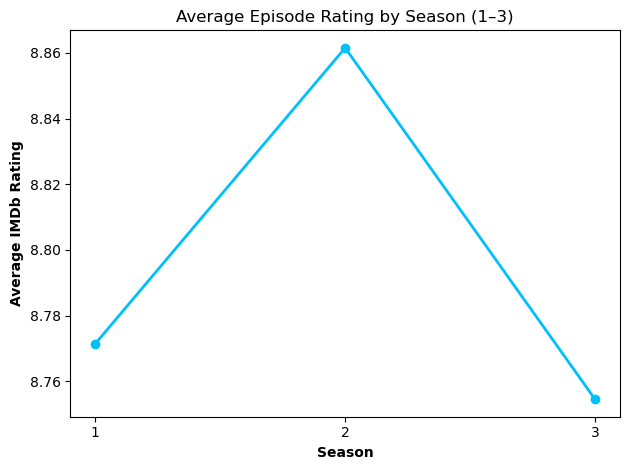

In [17]:
# get the average rating for each season
season_avg = episode.groupby('season')['rating'].mean()

# plot the trend line
plt.figure(facecolor='white')
season_avg.plot(kind='line', color=meth_blue, marker='o', linewidth=2)
plt.xlabel('Season',              fontweight='bold') #xlabel
plt.ylabel('Average IMDb Rating', fontweight='bold') #ylabel
plt.title('Average Episode Rating by Season (1–3)') # title
plt.xticks([1, 2, 3])
plt.tight_layout()
plt.show()

Ratings rise from Season 1 (8.77) to Season 2 (8.87), then dip slightly in Season 3 (8.75). The Season 2 peak aligns with the show's increasingly gripping storylines. The Season 3 dip may reflect a slower-paced mid-series build-up before its finale payoff and the audience starst getting the story. Overall, ratings remain consistently high across all three seasons, indicating strong audience approval throughout.

### 7. Dialogue Volume vs Rating

Here we will explore the relationship between dialogue count and Rating per episode.

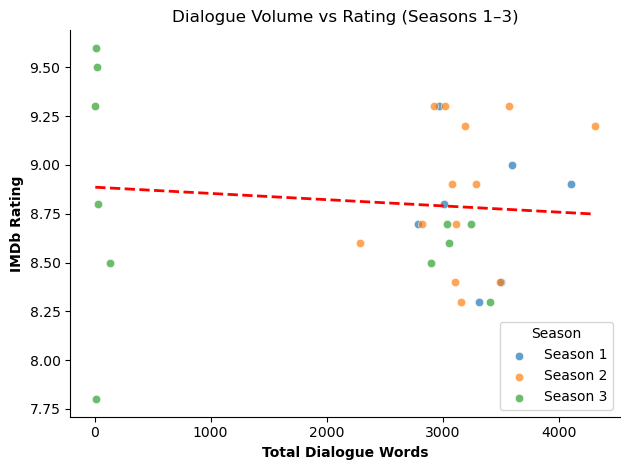

In [18]:
# do the math to find the slope (m) and intercept (b) for the trend line
m, b = np.polyfit(episode['word_count'], episode['rating'], 1)
x_line = np.linspace(episode['word_count'].min(), episode['word_count'].max(), 100) # make a bunch of x points between the min and max

plt.figure(facecolor='white') # setup the canvas and background white
for s, grp in episode.groupby('season'):
    plt.scatter(grp['word_count'], grp['rating'],
                alpha=0.7, edgecolors='white', linewidths=0.5, label=f'Season {s}')
plt.legend(title='Season')

plt.plot(x_line, m * x_line + b, color='red', linewidth=2,
         linestyle='--', label=f'Best Fit (slope={m:.5f})')
plt.xlabel('Total Dialogue Words', fontweight='bold') #xlabel
plt.ylabel('IMDb Rating',          fontweight='bold') #ylabel
plt.title('Dialogue Volume vs Rating (Seasons 1–3)')
sns.despine() #remove top an dright border
plt.tight_layout() # make the plot nicely fit
plt.show() 

The scatter plot shows no strong linear relationship between total word count and rating. Episodes with both lower and higher word counts received a widerange of ratings, suggesting that simply having more dialogue does not guarantee a better episode. There is however a noticeable cluster between just under 3000 and just 4000 words,where ratings generally fall between about 8.25 and 9.3. A few extreme outliers sit below 200 words and these are Season 3 episodes where the script data is clearly incomplete not the episodes that were that short. They do not follow the pattern of the rest of the data and ideally would be excluded in a more complete dataset. This concetration indicates that episodes within this dialogue range tend to perform consistently well, though overall, direct correlation remains weak. 

### 8. Walter White Dialogue Share

We measure Walter's prominence by calculating the fraction of total episode words he speaks.

In [19]:
char_words  = breaking_bad.groupby(['season','episode','actor'])['word_count'].sum().reset_index()
total_words = (breaking_bad.groupby(['season','episode'])['word_count']
                            .sum().reset_index()
                            .rename(columns={'word_count':'total_words'}))

char_words = char_words.merge(total_words, on=['season','episode'])
char_words['share']       = char_words['word_count'] / char_words['total_words']
char_words['actor_clean'] = char_words['actor'].str.strip().str.lower()

# Keep Walter White rows, exclude Walter Jr.
walter = char_words[
    (char_words['actor_clean'].str.contains('walter') |
     char_words['actor_clean'].str.contains(r'^walt$')) &
    (~char_words['actor_clean'].str.contains('jr'))
]
# sum it up per ep
walter = (walter.groupby(['season','episode'])['share']
                .sum().reset_index()
                .rename(columns={'share':'walter_share'}))
# joins his stats back to the main episode table
episode = episode.merge(walter, on=['season','episode'], how='left')
episode['walter_share'] = episode['walter_share'].fillna(0) # fill NAs with 0


### 9. Walter Dialogue Share vs Rating

Does more Walter mean a better-rated episode? We plot his dialogue share against episode rating to find out if his presence increases teh ratting.

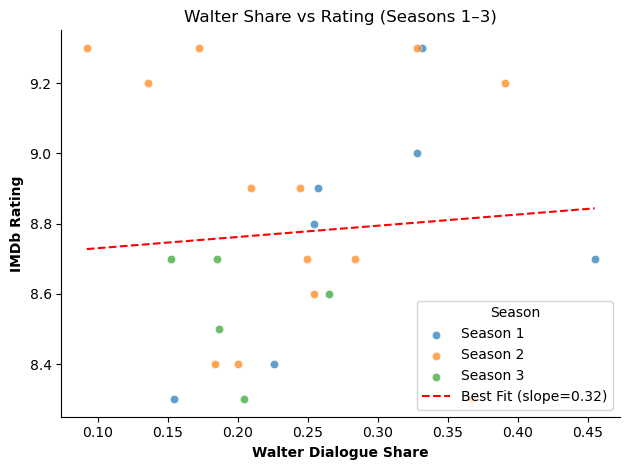

In [20]:
# filter out any eps where walt has no words
episode_filtered = episode[episode['walter_share'] > 0]

# do the math to find the slope (m) and intercept (b) for the trend line
m, b = np.polyfit(episode_filtered['walter_share'], episode_filtered['rating'], 1)
x_line = np.linspace(episode_filtered['walter_share'].min(),
                     episode_filtered['walter_share'].max(), 100)

fig, ax = plt.subplots(facecolor='white')
ax.set_facecolor('white')

for s, grp in episode_filtered.groupby('season'):
    ax.scatter(grp['walter_share'], grp['rating'],
               alpha=0.7, edgecolors='white', linewidths=0.5, label=f'Season {s}')

ax.plot(x_line, m * x_line + b, linestyle='--', color='red',
        label=f'Best Fit (slope={m:.2f})')
ax.set_xlabel('Walter Dialogue Share', fontweight='bold')
ax.set_ylabel('IMDb Rating',           fontweight='bold')
ax.set_title('Walter Share vs Rating (Seasons 1–3)')
ax.legend(title='Season')
sns.despine()
plt.tight_layout()
plt.show()

The above scatter plot suggests that episodes where Walter White has a higher share of dialogue tend to receive slightly higher ratings. Being that Walter has the role of the central character, it is not shocking that episodes more focused on him may resonate more strongly with viewers. The general upward pattern, reflected by a line of best fit, indicates a mild positive relationship between his dialogue share and episode ratings. There are noticeable outliers however, showing that some highly rated episodes exists even with lower involvement from Walter, and possibly with other key characters like Jesse, Gustavo and smaller storylines. 

### 10. Deaths per Season vs Average Rating (Seasons 1–3)

We compare total on-screen deaths per season against the season's average IMDb rating to explore whether more violent seasons tend to be rated higher.

In [21]:
deaths   = pd.read_csv("deaths.csv").query('season <= 3')
deaths_per_season = (
    deaths.groupby('season')['number_of_deaths']
          .sum().reset_index()
          .rename(columns={'number_of_deaths': 'Deaths'})
)

rating_per_season = (
    episode.groupby('season')['rating']
           .mean().reset_index()
           .rename(columns={'rating': 'Avg Rating'})
)

season_summary = deaths_per_season.merge(rating_per_season, on='season')

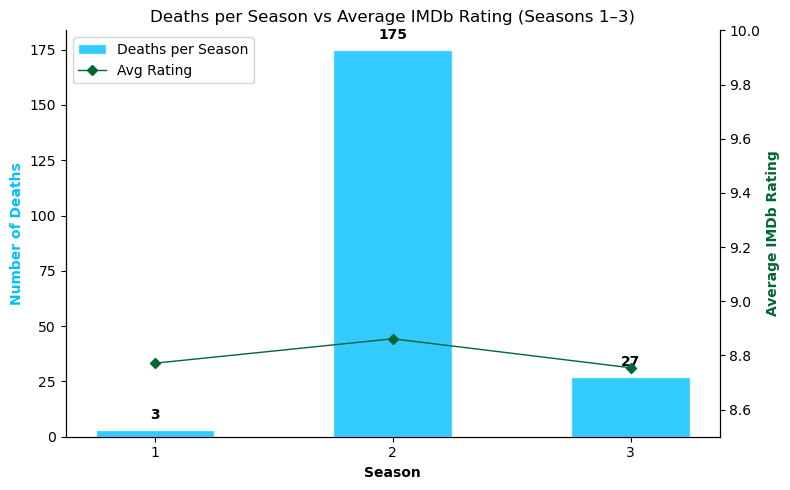

In [22]:
# setup plot
fig, ax1 = plt.subplots(figsize=(8, 5), facecolor='white')
ax1.set_facecolor('white')

# make bar chart for deaths
bars = ax1.bar(season_summary['season'], season_summary['Deaths'],
               color=meth_blue, alpha=0.8, edgecolor='white',
               width=0.5, label='Deaths per Season')

for bar in bars: # add numbers on top of bars
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() +5,
             str(int(bar.get_height())),
             ha='center', fontsize=10, fontweight='bold')
# add labels
ax1.set_xlabel('Season', fontweight='bold')
ax1.set_ylabel('Number of Deaths', color=meth_blue, fontweight='bold')
ax1.set_xticks([1, 2, 3])

# add a second axis for rating lin
ax2 = ax1.twinx()
ax2.plot(season_summary['season'], season_summary['Avg Rating'],
         color=toxic_green, marker='D', linewidth=1,
         markersize=5, label='Avg Rating')
ax2.set_ylabel('Average IMDb Rating', color=toxic_green, fontweight='bold')
ax2.set_ylim(8.5, 10)

plt.title('Deaths per Season vs Average IMDb Rating (Seasons 1–3)')
lines1, labels1 = ax1.get_legend_handles_labels() # combine legends
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
sns.despine(right=False)
plt.tight_layout()
plt.show()

Season 1 has very few deaths (3), reflecting the show's early focus on character building over violence. 
Season 2 spikes dramatically to (175) almost entirely driven by the Wayfarer 515 plane crash, a 
single catastrophic event that was itself a consequence of Walt's choices. Season 3 settles at (27) 
with the arrival of the Cousins and cartel conflict. Ratings remain high across all three seasons 
with a slight peak in Season 2. This is suggesting that high-stakes consequences even accidental ones 
rooted in Walt's actions means more plot twist and more uncertainity thus resonate strongly with viewers. 

### 11. Basic Modelling – OLS Regression

We fit an Ordinary Least Squares regression:

> **rating ~ walter_share ~ season**

This measures which predictors are statistically associated with higher ratings while holding the others constant. We plot **predicted vs actual ratings** to assess model fit.

In [23]:
# run a simple regresion
model = smf.ols('walter_share ~ season', data=episode).fit()
# dump the full summry table to check th stats
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           walter_share   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     19.18
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           0.000142
Time:                        03:36:19   Log-Likelihood:                 28.931
No. Observations:                  31   AIC:                            -53.86
Df Residuals:                      29   BIC:                            -50.99
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4165      0.053      7.841      0.0

The model produced a an R-squared of 0.398, which explains in a season around 40% of the variation is in Walter's dialogue share. This is a strong result for a single predictor OLS model.The season coefficient is -0.103 which is was actually surprising to us as it is negative.  Negative season coefficent means Walter speaks less as a share of total dialogue as new seasons comes. In Season 1 he accounts for roughly 42% of all dialogue, falling by about 10 percentage points each season through to Season 3.

Looking back at the show this makes sense though. Season 1 is almost entirely Walter's story. By Season 3, Jesse, Skyler, Hank and Gus all have their own major storylines which naturally reduces Walter's share of the conversation even as his influence in the drug world grows. The show shifts from a one-man character study to a full ensemble, and this model which is pretty interesting to see in the numbers.This is a useful first step. A more complete model could include Jesse's dialogue share or sentiment scores to better understand how the show's focus shifts across seasons.

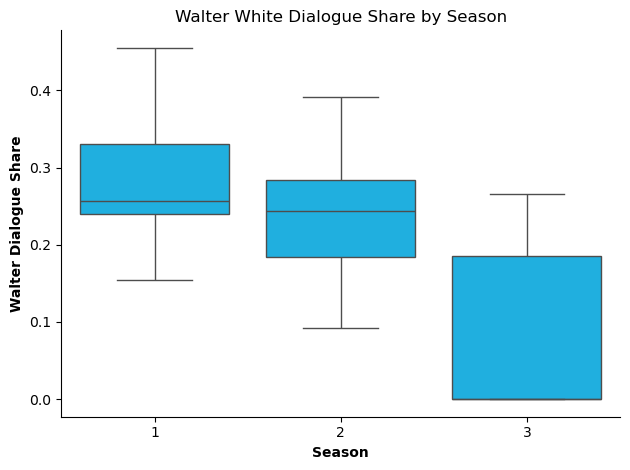

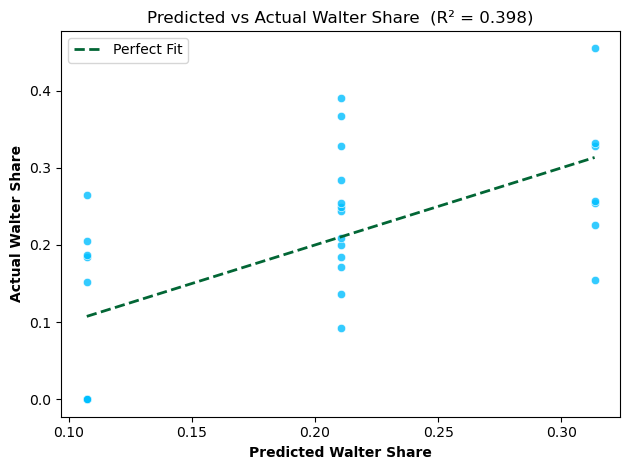

In [24]:
# Boxplot to show distribution for each season
plt.figure(facecolor='white')
sns.boxplot(data=episode, x='season', y='walter_share', color=meth_blue)
plt.xlabel('Season',                fontweight='bold') #xlabel
plt.ylabel('Walter Dialogue Share', fontweight='bold') #ylabel
plt.title('Walter White Dialogue Share by Season')
sns.despine()
plt.tight_layout()
plt.show()

# Predicted vs actual to show model fit
episode['predicted'] = model.fittedvalues
plt.figure(facecolor='white')
plt.scatter(episode['predicted'], episode['walter_share'],
            color=meth_blue, alpha=0.8, edgecolors='white', linewidths=0.5)

# line for best fit 
plt.plot([episode['predicted'].min(), episode['predicted'].max()],
         [episode['predicted'].min(), episode['predicted'].max()],
         color=toxic_green, linewidth=2, linestyle='--', label='Perfect Fit')
plt.xlabel('Predicted Walter Share', fontweight='bold') #xlabel
plt.ylabel('Actual Walter Share',    fontweight='bold') # ylabel
plt.title(f'Predicted vs Actual Walter Share  (R\u00b2 = {model.rsquared:.3f})')
plt.legend() #adds legend 
plt.tight_layout()
plt.show()

The box plot shows Walters dialogue share dropping each season which visually confirms what 
the regression found. Season 1 has the highest median share and Season 3 the lowest with a 
noticeable downward trend across the three boxes. The predicted vs actual plot looks a bit unusual at first. The dots form three vertical columns 
because season only takes three values so the model assigns one predicted share per season 
rather than a unique value per episode. The spread within each column is the episode to episode 
variation that the model cannot capture which is why R² sits at 0.398 rather than closer to 1.

Overall both plots confirm that season is a useful but incomplete predictor of Walters dialogue 
share. The general trend is clear but individual episodes vary quite a bit depending on their 
specific storyline.

### 12. Conclusions

This analysis examined whether dialogue quantity, character prominence, and on-screen deaths help explain variation in Breaking Bad's IMDb ratings across Seasons 1–3. Overall ratings are consistently high across all three seasons with Season 2 peaking slightly at around 8.9. This reflects the shows narrative rhythm where tension builds, peaks and resets heading into the next season. When it comes to dialogue volume we found no meaningful relationship with rating. Episodes with more words are not better rated which tells us that how much is said matters far less than what is actually happening in the episode.

The deaths analysis showed that as the show gets more violent across Seasons 1 to 3 ratings stay high and even climb slightly. Season 2 spikes dramatically due to the plane crash and Season 3 sees the arrival of the Cousins bringing more intentional violence. This suggests 
that escalating stakes keep viewers engaged. The most interesting finding came from the regression model. We expected Walter to dominate more as the seasons go on but the opposite is true. His dialogue share actually decreases by roughly 10 percentage points each season. Because as Jesse, Skyler, Hank and Gus all develop into major characters alongside him things gets serious. The show stops being just Walters story and starts being about everyone around him and the model picks this up clearly with an R-squared of 0.398.

One thing that limits our findings is that we only have 30 episodes. With only 30 episodes across Seasons 1 to 3 the statistical power is modest. It would be cool to also look at would be to add sentiment analysis to the dialogue or bring in full series scripts to see how these patterns continue into the 
later seasons.